# BRP Exploration and Field Sample

This is the first notebook in the project. BRP stands for "Basisregistratie Percelen", it's the Dutch government's yearly registry of every agricultural field in the country and what crop is grown on it. This notebook loads that raw data, cleans it up, and picks out a smaller, labeled sample of fields to use later. The output of this notebook is the input for the next one (the satellite notebook).

## Loading the BRP Data

First, I load the BRP geopackage (a geopackage is just a file format for storing map data, basically a shapefile with extra info). I check the columns to see what information is in there, and I check the coordinate system (CRS), which tells me how locations are measured in this file. This matters later because I'll need to match this up with the satellite data, which uses a different coordinate system.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box

BRP_PATH = "../data/brp_2025.gpkg"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 40)

brp_gdf = gpd.read_file(BRP_PATH)

print("Total parcels:", len(brp_gdf))
print("CRS:", brp_gdf.crs)

print("Columns:")
for column in brp_gdf.columns:
    print(column)

display(brp_gdf.head())


/Users/rickpeters/Desktop/YieldPredictionModel/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


Total parcels: 2331084
CRS: EPSG:28992
Columns:
category
gewas
gewascode
jaar
status
geometry


,category,gewas,gewascode,jaar,status,geometry
0,Landschapselement,Sloot,343,2025,Definitief,"POLYGON ((65544.876 383512.682, 65557.222 3835..."
1,Bouwland,"Overige bloemen, overige bloemkwekerijgewassen",991,2025,Definitief,"POLYGON ((68230.247 382132.963, 68297.306 3821..."
2,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((112088.897 458665.931, 112085.119 45..."
3,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((113219.88 456644.96, 113220.052 4566..."
4,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((113236.78 456777.5, 113237.28 456777..."


## Exploring Crops and Field Sizes


Next, I look at the crop label column (called gewas, which is Dutch for "crop"). I check how many different crop types are in there, which ones are the most common, and how big the fields usually are. This gives me a sense of what I'm working with before I start filtering anything.


gewas
['Sloot', 'Overige bloemen, overige bloemkwekerijgewassen', 'Grasland, blijvend', 'Grasland, blijvend', 'Grasland, blijvend', 'Grasland, blijvend', 'Uien, gele zaai-', 'Broccoli, productie', 'Broccoli, productie', 'Mais, snij-']

gewascode
[343, 991, 265, 265, 265, 265, 6660, 2719, 2719, 259]
Unique crop categories: 370
Top 10 crop share: 86.96 %


,crop,parcel_count,percentage
0,Sloot,815501,34.98
1,"Grasland, blijvend",629359,27.00
2,"Grasland, tijdelijk",139766,6.00
3,"Mais, snij-",95192,4.08
4,Houtwal en houtsingel,82124,3.52
5,"Groene braak, spontane opkomst",77223,3.31
6,Agrarisch natuurmengsel,68637,2.94
7,"Grasland, natuurlijk. Met landbouwactiviteiten.",67699,2.90
8,Natuurterreinen (incl. heide),30624,1.31
9,"Tarwe, winter-",21096,0.90


count    2.331084e+06
mean     8.201558e-01
std      3.205996e+00
min      1.182529e-06
25%      1.682330e-02
50%      5.573904e-02
75%      6.169048e-01
max      2.127358e+03
Name: area_ha, dtype: float64

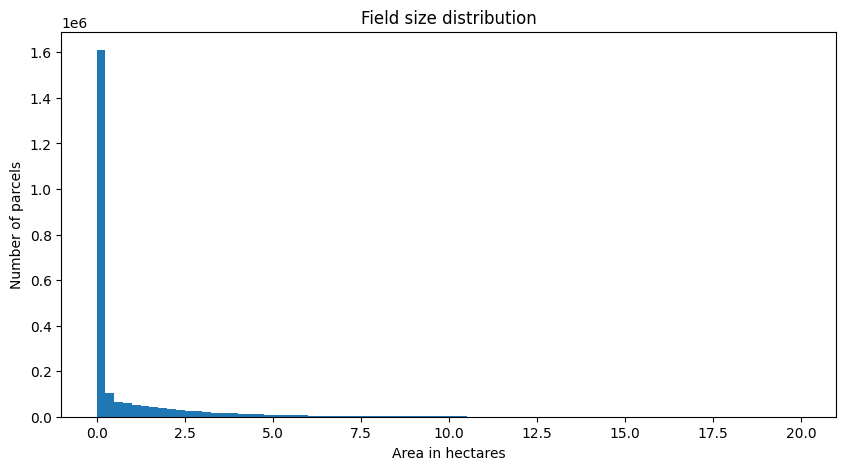

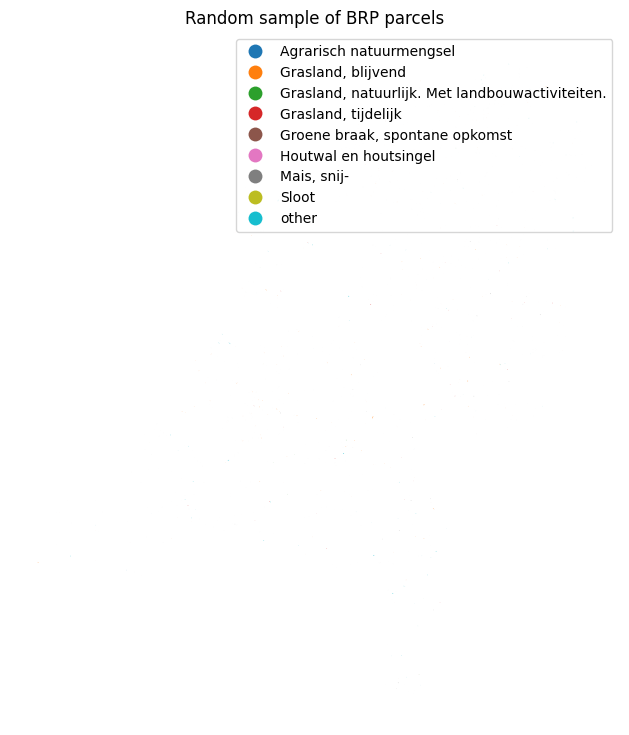

In [2]:
CROP_COLUMN = "gewas"

for column in brp_gdf.columns:
    if "gewas" in column.lower():
        print()
        print(column)
        print(brp_gdf[column].dropna().head(10).tolist())

crop_counts = brp_gdf[CROP_COLUMN].fillna("Unknown").value_counts()

top_30_crops = crop_counts.head(30).reset_index()
top_30_crops.columns = ["crop", "parcel_count"]
top_30_crops["percentage"] = top_30_crops["parcel_count"] / len(brp_gdf) * 100
top_30_crops["percentage"] = top_30_crops["percentage"].round(2)

print("Unique crop categories:", brp_gdf[CROP_COLUMN].nunique())
print("Top 10 crop share:", round(crop_counts.head(10).sum() / len(brp_gdf) * 100, 2), "%")
display(top_30_crops)

brp_gdf["area_ha"] = brp_gdf.geometry.area / 10000

area_summary = brp_gdf["area_ha"].describe()
display(area_summary)

plt.figure(figsize=(10, 5))
plt.hist(brp_gdf["area_ha"], bins=80, range=(0, 20))
plt.title("Field size distribution")
plt.xlabel("Area in hectares")
plt.ylabel("Number of parcels")
plt.show()

top_8_crops = crop_counts.head(8).index.tolist()
map_sample = brp_gdf.sample(1000, random_state=42).copy()

map_sample["crop_group"] = "other"
map_sample.loc[map_sample[CROP_COLUMN].isin(top_8_crops), "crop_group"] = map_sample[CROP_COLUMN]

map_sample.plot(column="crop_group", categorical=True, legend=True, figsize=(9, 9))
plt.title("Random sample of BRP parcels")
plt.axis("off")
plt.show()


## Selecting the Region and Crop Parcels


The full BRP file covers the entire Netherlands, which is way more data than I need for this project. So to keep things simple, I'm zooming in on one smaller area. I picked a region that roughly covers Eindhoven, Tilburg, Den Bosch, and Boekel. From here on, I only work with fields inside this region.

Parcels in region: 69871


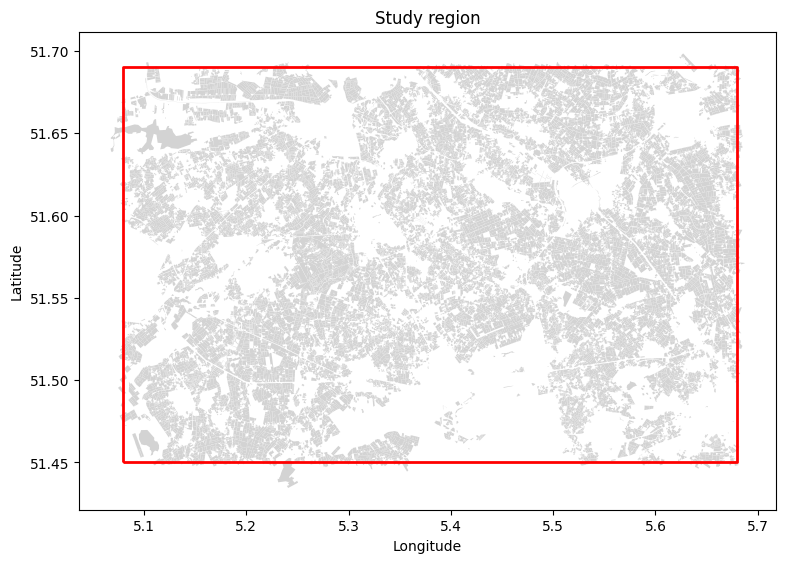

,category,parcel_count
0,Landschapselement,28749
1,Grasland,23026
2,Bouwland,16847
3,Natuurterrein,1041
4,Overige,193
5,Braakland,15


Crop parcels after category filter: 39873


,crop,parcel_count
0,"Grasland, blijvend",12318
1,"Mais, snij-",6658
2,"Grasland, tijdelijk",6068
3,"Grasland, natuurlijk. Met landbouwactiviteiten.",2665
4,"Groene braak, spontane opkomst",2606
5,Agrarisch natuurmengsel,1608
6,"Aardappelen, consumptie",1266
7,"Laanbomen/parkbomen, opzetters, open grond",722
8,"Bieten, suiker-",384
9,"Grasland, natuurlijk. Hoofdfunctie natuur.",367


In [3]:
min_lon = 5.08
min_lat = 51.45
max_lon = 5.68
max_lat = 51.69

region_box = box(min_lon, min_lat, max_lon, max_lat)
region_box_gdf = gpd.GeoDataFrame(geometry=[region_box], crs="EPSG:4326")

brp_wgs84 = brp_gdf.to_crs("EPSG:4326")
brp_region = brp_wgs84[brp_wgs84.intersects(region_box)].copy()

print("Parcels in region:", len(brp_region))

ax = brp_region.plot(color="lightgray", edgecolor="none", figsize=(9, 7))
region_box_gdf.boundary.plot(ax=ax, color="red", linewidth=2)
plt.title("Study region")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

category_counts = brp_region["category"].fillna("Unknown").value_counts().reset_index()
category_counts.columns = ["category", "parcel_count"]
display(category_counts)

wanted_categories = ["Bouwland", "Grasland"]
brp_cropland = brp_region[brp_region["category"].isin(wanted_categories)].copy()

print("Crop parcels after category filter:", len(brp_cropland))

top_20_crops = brp_cropland[CROP_COLUMN].value_counts().head(20).reset_index()
top_20_crops.columns = ["crop", "parcel_count"]
display(top_20_crops)


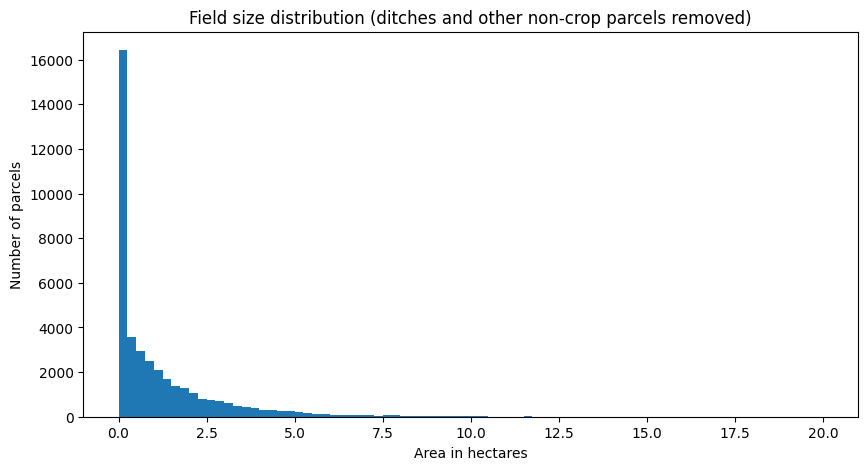

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(brp_cropland["area_ha"], bins=80, range=(0, 20))
plt.title("Field size distribution (ditches and other non-crop parcels removed)")
plt.xlabel("Area in hectares")
plt.ylabel("Number of parcels")
plt.show()

## Create and Save the Training Field Sample

Last step in this notebook. I remove the really small fields, since tiny fields tend to give messy, unreliable satellite readings later on. I also group the many detailed BRP crop names into seven broader, simpler classes (like "Maize" or "Potato"), again just to keep things manageable. Once that's done, I save this cleaned up sample of fields so the next notebook can pick it up and add satellite data to it.

In [4]:
brp_cropland["area_ha"] = brp_gdf.loc[brp_cropland.index, "area_ha"]
brp_filtered = brp_cropland[brp_cropland["area_ha"] >= 0.5].copy()

print("Fields after size filter:", len(brp_filtered))
display(brp_filtered["area_ha"].agg(["min", "max", "mean", "median"]))

def crop_class(crop_name):
    crop_name = "" if pd.isna(crop_name) else str(crop_name)

    if crop_name.startswith("Grasland"):
        return "Grass"
    elif crop_name.startswith("Mais"):
        return "Maize"
    elif crop_name.startswith("Aardappelen"):
        return "Potato"
    elif crop_name.startswith("Tarwe"):
        return "Wheat"
    elif crop_name.startswith("Gerst"):
        return "Barley"
    elif crop_name.startswith("Bieten, suiker-"):
        return "Sugar beet"
    elif crop_name.startswith("Uien"):
        return "Onion"
    else:
        return "Other"

brp_filtered["crop_class"] = brp_filtered[CROP_COLUMN].apply(crop_class)

class_counts = brp_filtered["crop_class"].value_counts().reset_index()
class_counts.columns = ["crop_class", "parcel_count"]
class_counts["percentage"] = class_counts["parcel_count"] / len(brp_filtered) * 100
display(class_counts)

training_fields = brp_filtered[brp_filtered["crop_class"] != "Other"].copy()

sampled_groups = []
for crop_name in training_fields["crop_class"].unique():
    one_crop = training_fields[training_fields["crop_class"] == crop_name]

    if len(one_crop) > 800:
        one_crop = one_crop.sample(800, random_state=42)

    sampled_groups.append(one_crop)

sampled_fields = pd.concat(sampled_groups)
sampled_fields = sampled_fields.sort_index()

sample_counts = sampled_fields["crop_class"].value_counts().reset_index()
sample_counts.columns = ["crop_class", "field_count"]
display(sample_counts)
print("Total sampled fields:", len(sampled_fields))

sample_output_path = "../data/sampled_fields.gpkg"
columns_to_save = [CROP_COLUMN, "crop_class", "area_ha", "geometry"]

sample_to_save = sampled_fields[columns_to_save].copy()
sample_to_save = sample_to_save.to_crs("EPSG:4326")
sample_to_save.to_file(sample_output_path, layer="sampled_fields", driver="GPKG")

print("Saved file:", sample_output_path)


Fields after size filter: 19880


min        0.500017
max       35.004724
mean       2.247107
median     1.618870
Name: area_ha, dtype: float64

,crop_class,parcel_count,percentage
0,Grass,10318,51.901408
1,Maize,4803,24.159960
2,Other,3009,15.135815
3,Potato,1047,5.266600
4,Sugar beet,297,1.493964
5,Onion,164,0.824950
6,Wheat,131,0.658954
7,Barley,111,0.558350


,crop_class,field_count
0,Grass,800
1,Potato,800
2,Maize,800
3,Sugar beet,297
4,Onion,164
5,Wheat,131
6,Barley,111


Total sampled fields: 3103
Saved file: ../data/sampled_fields.gpkg


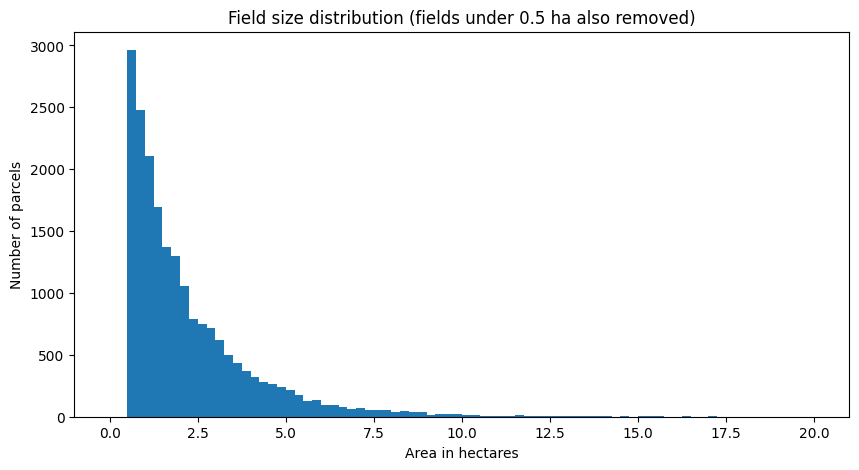

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(brp_filtered["area_ha"], bins=80, range=(0, 20))
plt.title("Field size distribution (fields under 0.5 ha also removed)")
plt.xlabel("Area in hectares")
plt.ylabel("Number of parcels")
plt.show()